In [1]:
import cosima_cookbook as cc
from cosima_cookbook import distributed as ccd
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

In [2]:
client = Client(n_workers = 28)

2025-08-14 14:59:48,009 - distributed.protocol.core - CRITICAL - Failed to Serialize
Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/distributed/protocol/core.py", line 109, in dumps
    frames[0] = msgpack.dumps(msg, default=_encode_default, use_bin_type=True)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/msgpack/__init__.py", line 36, in packb
    return Packer(**kwargs).pack(o)
  File "msgpack/_packer.pyx", line 294, in msgpack._cmsgpack.Packer.pack
  File "msgpack/_packer.pyx", line 300, in msgpack._cmsgpack.Packer.pack
  File "msgpack/_packer.pyx", line 297, in msgpack._cmsgpack.Packer.pack
  File "msgpack/_packer.pyx", line 264, in msgpack._cmsgpack.Packer._pack
  File "msgpack/_packer.pyx", line 231, in msgpack._cmsgpack.Packer._pack
  File "msgpack/_packer.pyx", line 264, in msgpack._cmsgpack.Packer._pack
  File "msgpack/_packer.pyx", line 202, in msgpa

In [3]:
	session = cc.database.create_session('/home/156/wf4500/databases/access/panan005_rerun.db') #panan005
	#session = cc.database.create_session() #panan01
	
	start_time='1999-01-01'     
	end_time='2001-12-31'
	#Start_time0 and end_time0 are for importing the daily transport, and it ahsthe number of days in the month    
	start_time0='1999-01-01'     
	end_time0='2001-12-31'
	print(start_time0) 
	print(end_time0) 
	exp = 'panan01_yr2000_HTsigma'
	
	print("Start date =" + start_time) 
	year2=str(int(start_time[0:4])+1)
	month2=str(int(start_time[5:7])+1)
	month2=str(int(month2))
	month2 = month2.zfill(2)    
	print("month2 is =" + month2) 
	print("year2 is =" + str(year2))     
	
	print("End date =" + end_time) 
	
	
	time_period = str(int(start_time[:4]))+'-'+str(int(end_time[:4]))
	
	# reference density value:
	rho_0 = 1035.0
	# specific heat capacity of sea water:
	cp = 3992.1
	lat_range = slice(-90,-59)
	
	isobath_depth = 1000
	
	# pick a freezing point temp:
	temp_freezing = -1.9
	

1999-01-01
2001-12-31
Start date =1999-01-01
month2 is =02
year2 is =2000
End date =2001-12-31


In [4]:
start_time0='2000-01-01'
end_time0='2000-12-31'
volcello = cc.querying.getvar('panant-005-zstar-ACCESSyr2','volcello',session,ncfile='%month_rho2.nc',\
                          start_time=start_time,end_time=end_time)\
.sel(time=slice(start_time,end_time))
temp = cc.querying.getvar('panant-005-zstar-ACCESSyr2','thetao',session,ncfile='%month_rho%',\
                          start_time=start_time,end_time=end_time)\
.sel(time=slice(start_time,end_time))
temp_masked = temp.where(volcello>1.5E-1) #Masking off temperature in non-existing density layers
#minimuns and maximuns
minT = temp_masked.min().compute(); maxT = temp_masked.max().compute()

In [5]:
print('Min temperature is ' + str(minT.values) + ' Celsius, ' +\
      'Max temperature is ' + str(maxT.values) + ' Celsius')

Min temperature is -328.7495 Celsius, Max temperature is 5831.399 Celsius


In [6]:
#sanity check on the masking
n = 2
volcello_t0masked = volcello.isel(time=n).where(volcello.isel(time=n)>1.5E-1)
volcello_t0masked.min().values
print('Min volcello is ' + str(volcello_t0masked.min().values) + ' m3 ')

Min volcello is 3.808407 m3 


In [7]:
temp_zonalmin = temp_masked.min('time').min('xh').compute()
temp_zonalmax = temp_masked.max('time').max('xh').compute()
#lets try it at a monthly mean output

temp_zonalmin_t0 = temp_masked.isel(time=n).min('xh').compute()
temp_zonalmax_t0 = temp_masked.isel(time=n).max('xh').compute()

(-80.0, -60.0)

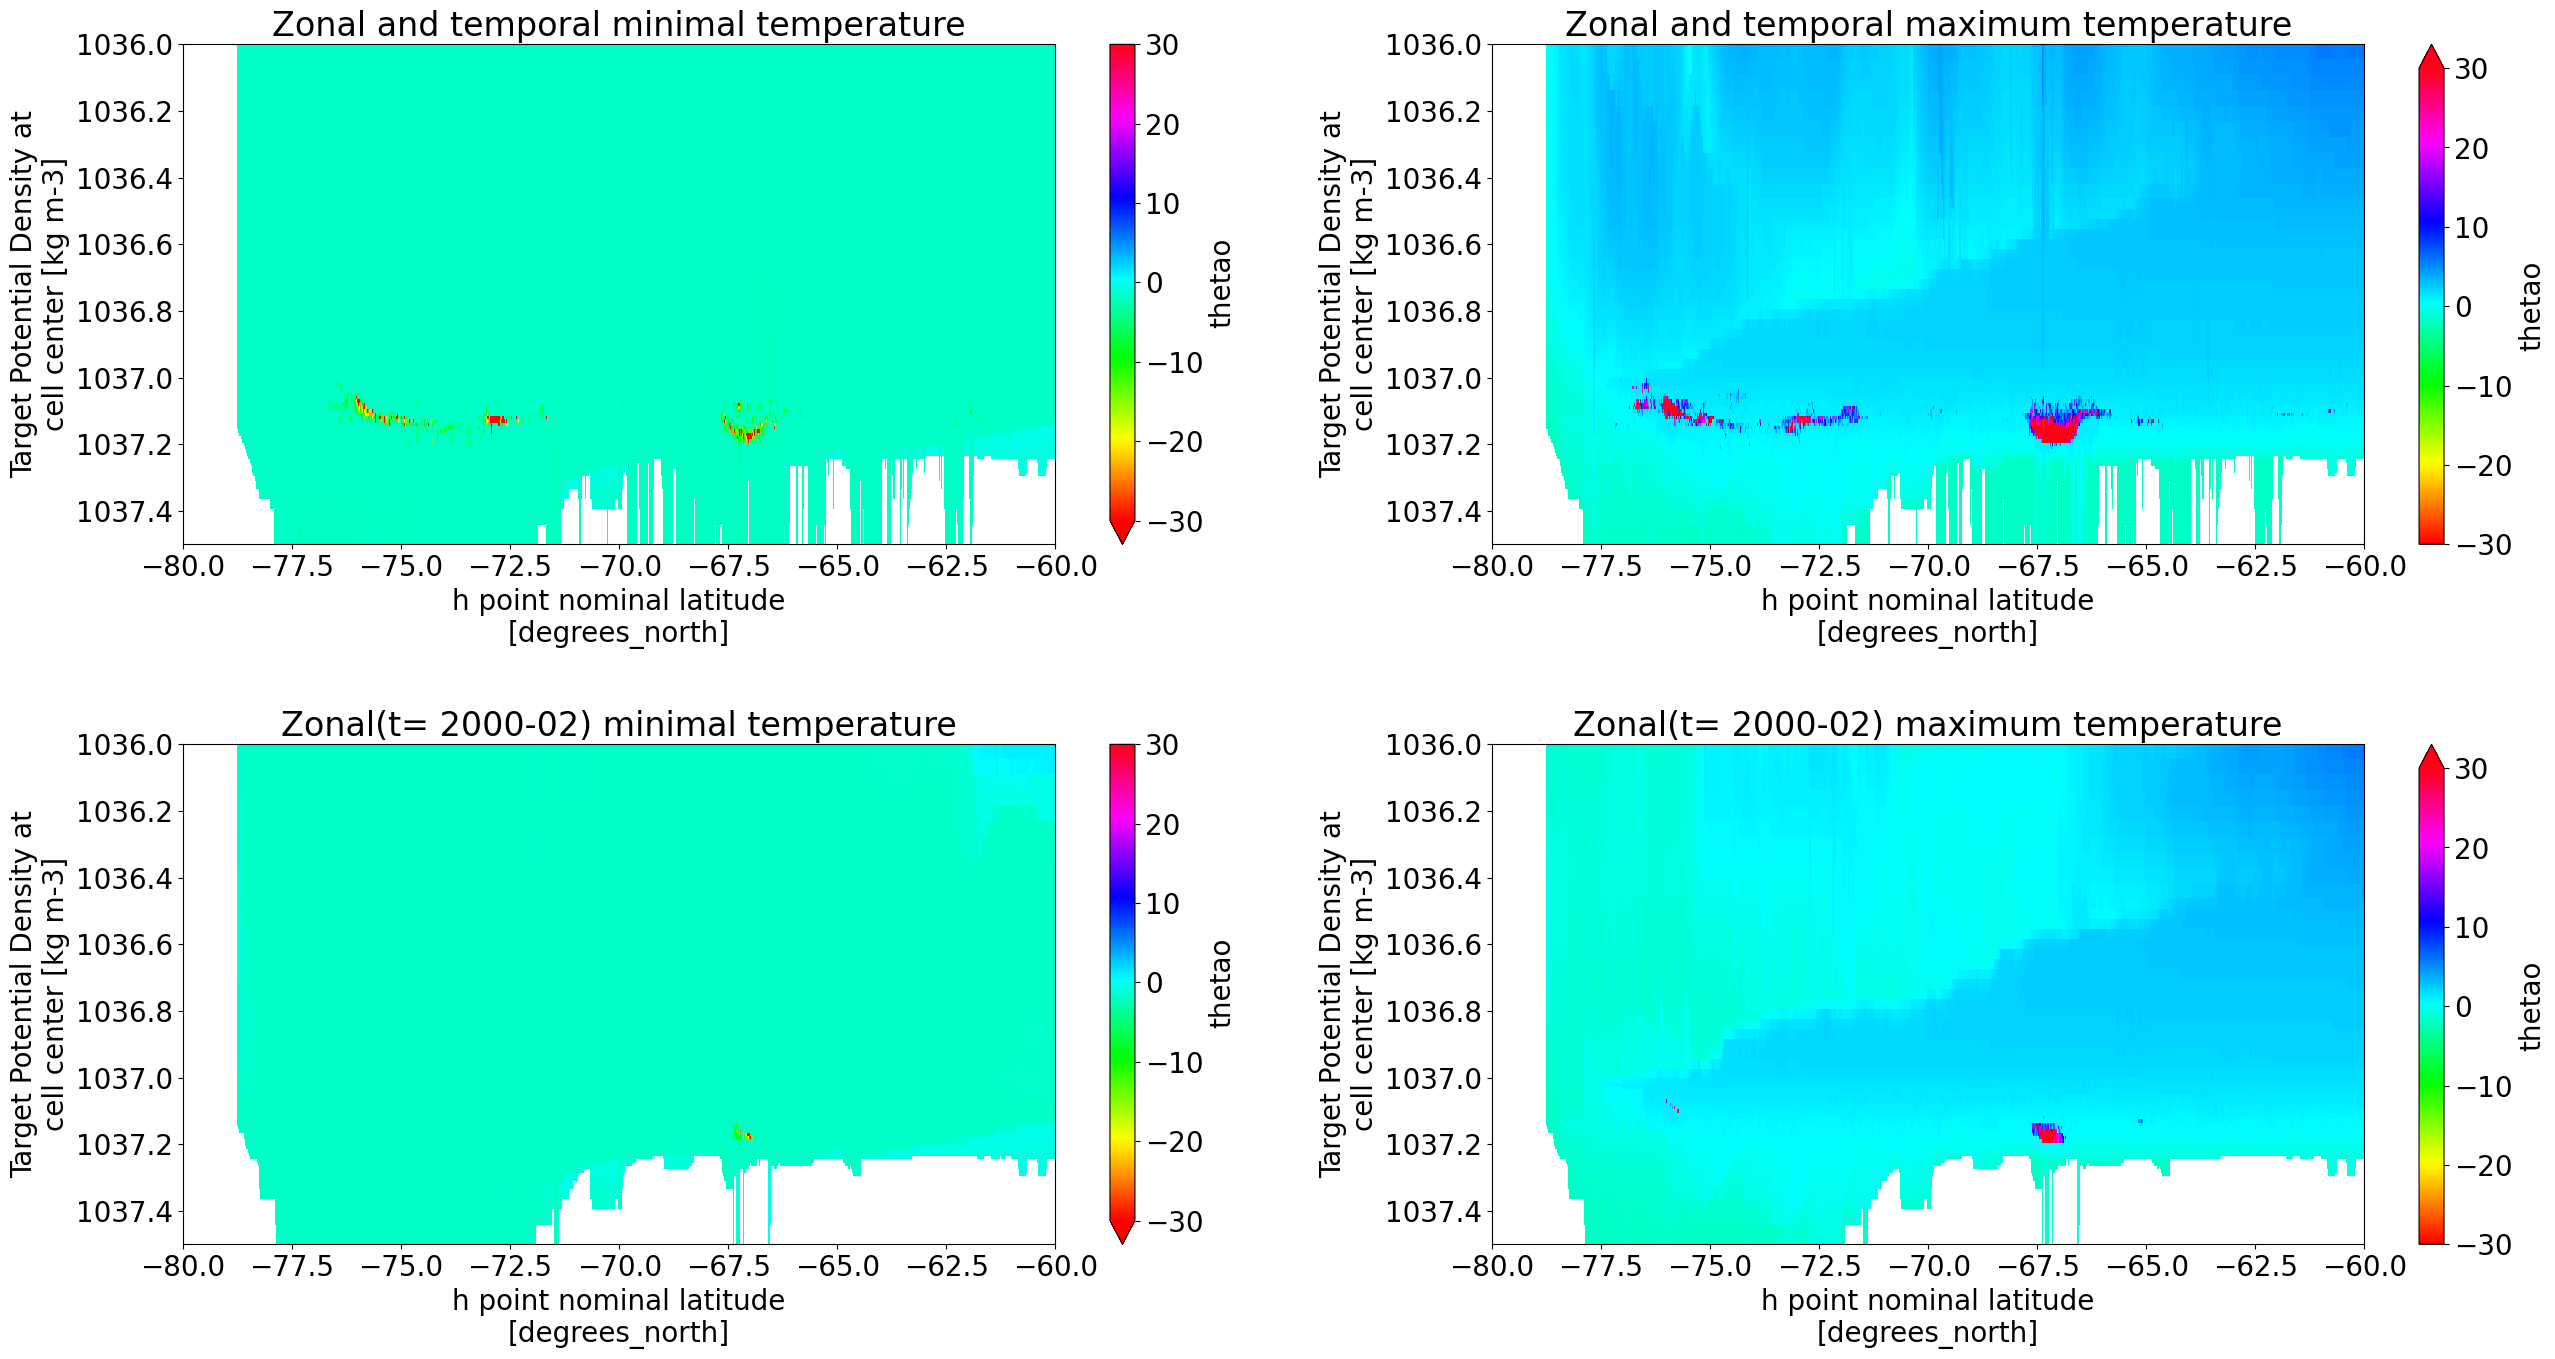

In [10]:
plt.figure(figsize=(30,15))
plt.subplots_adjust(left=0.1,bottom=0.1, right=0.9, top=0.9, wspace=0.2, hspace=0.4)
plt.rcParams.update({'font.size': 20})

plt.subplot(2,2,1)
temp_zonalmin.plot.pcolormesh(y='rho2_l',vmin=-30,vmax=30,cmap='hsv')
plt.title('Zonal and temporal minimal temperature')
plt.ylim(1037.5,1036)
plt.xlim(-80,-60)

plt.subplot(2,2,2)
temp_zonalmax.plot.pcolormesh(y='rho2_l',vmin=-30,vmax=30,cmap='hsv')
plt.title('Zonal and temporal maximum temperature')
plt.ylim(1037.5,1036)
plt.xlim(-80,-60)

plt.subplot(2,2,3)
temp_zonalmin_t0.plot.pcolormesh(y='rho2_l',vmin=-30,vmax=30,cmap='hsv')
plt.title('Zonal(t= 2000-0' +  str(n) + ') minimal temperature')
plt.ylim(1037.5,1036)
plt.xlim(-80,-60)

plt.subplot(2,2,4)
temp_zonalmax_t0.plot.pcolormesh(y='rho2_l',vmin=-30,vmax=30,cmap='hsv')
plt.title('Zonal(t= 2000-0' +  str(n) + ') maximum temperature')
plt.ylim(1037.5,1036)
plt.xlim(-80,-60)

In [11]:
tempmin_t0masked = temp.isel(time=n).where(volcello.isel(time=n)>5E9).min()
tempmax_t0masked = temp.isel(time=n).where(volcello.isel(time=n)>5E9).max()
print('Min temperature is ' + str(tempmin_t0masked.values) + ' Celsius, ' +\
      'Max temperature is ' + str(tempmax_t0masked.values) + ' Celsius')

Min temperature is -1.6163329 Celsius, Max temperature is 13.540552 Celsius


In [12]:
%%time
tempmin_t0masked = temp.where(volcello>5E9).min()
tempmax_t0masked = temp.where(volcello>5E9).max()
print('Min temperature is ' + str(tempmin_t0masked.values) + ' Celsius, ' +\
      'Max temperature is ' + str(tempmax_t0masked.values) + ' Celsius')

Min temperature is -1.8722293 Celsius, Max temperature is 16.98767 Celsius
CPU times: user 16min 50s, sys: 59.9 s, total: 17min 50s
Wall time: 18min 48s


Vertical means to check geographically

In [13]:
temp_vmin = temp_masked.min('time').min('rho2_l').compute()
temp_vmax = temp_masked.max('time').max('rho2_l').compute()


(-80.0, -60.0)

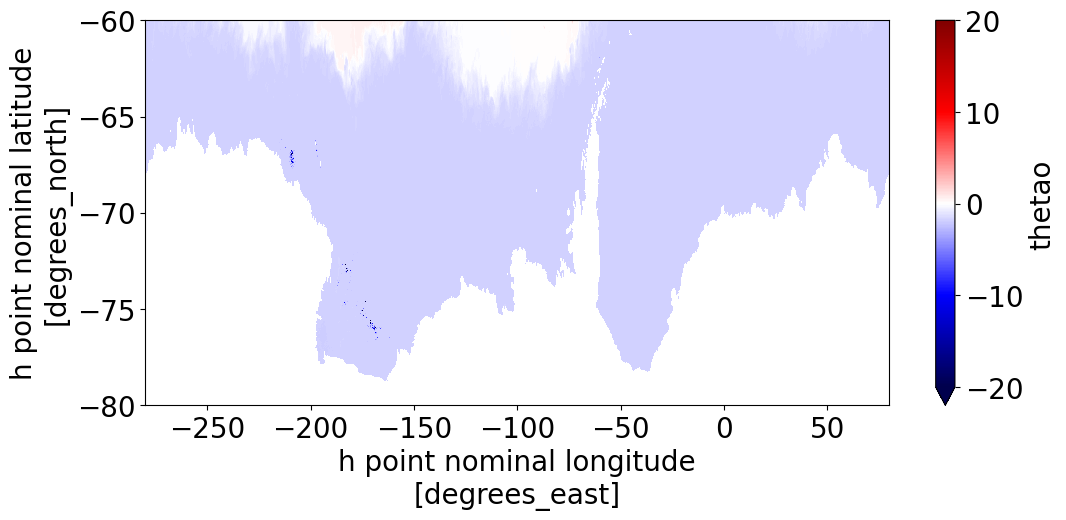

In [14]:
plt.figure(figsize = (12,5))
temp_vmin.plot(vmin=-20,vmax=20,cmap='seismic')
plt.ylim(-80,-60)

(-80.0, -60.0)

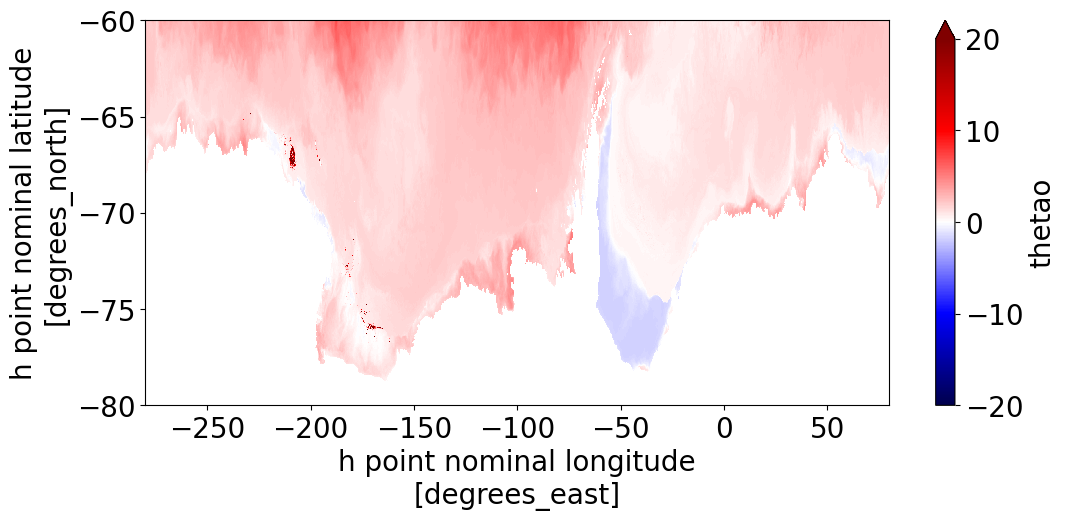

In [15]:
plt.figure(figsize = (12,5))
temp_vmax.plot(vmin=-20,vmax=20,cmap='seismic')
plt.ylim(-80,-60)

## Part 2, figuring out the layer thickness and volume of these weird cells

In [16]:
tarea = cc.querying.getvar('panant-005-zstar-ACCESSyr2','areacello',session,n=1)

In [17]:
drhot = volcello /tarea

In [18]:
#longitude slice where the spurious temperature happen
lon_slice = slice(-250,-150)
lat_slice = slice(-80,-65)

#cutting diagnostic data into the slices we want
temp_masked_sliced = temp_masked.sel(xh = lon_slice, yh= lat_slice)
drhot_sliced = drhot.sel(xh = lon_slice, yh= lat_slice)

In [19]:
temp_masked_sliced_negspurious = temp_masked_sliced.where(temp_masked_sliced < -10)
temp_masked_sliced_posspurious = temp_masked_sliced.where(temp_masked_sliced > 30)

In [20]:
temp_masked_sliced_negspurious = temp_masked_sliced_negspurious.dropna(dim='rho2_l',how='all').dropna(dim='xh',how='all').dropna(dim='yh',how='all')

In [21]:
temp_masked_sliced_posspurious = temp_masked_sliced_posspurious.dropna(dim='rho2_l',how='all').dropna(dim='xh',how='all').dropna(dim='yh',how='all')

In [22]:
%%time
temp_masked_sliced_negspurious.load()
temp_masked_sliced_posspurious.load()
print('matrix with supurious values loaded')

matrix with supurious values loaded
CPU times: user 35 s, sys: 2.56 s, total: 37.6 s
Wall time: 38.6 s


In [23]:
#stacking to ge the locations and timestamps
temp_masked_sliced_posspurious_stacked = temp_masked_sliced_posspurious.stack(generic = ('time','rho2_l','xh','yh'))
temp_masked_sliced_posspurious_stacked = temp_masked_sliced_posspurious_stacked.dropna(dim='generic')

temp_masked_sliced_negspurious_stacked = temp_masked_sliced_negspurious.stack(generic = ('time','rho2_l','xh','yh'))
temp_masked_sliced_negspurious_stacked = temp_masked_sliced_negspurious_stacked.dropna(dim='generic')

In [24]:
#extracting the dzt of these spurious values
drhot_negspurious_stacked = drhot.sel(xh = temp_masked_sliced_negspurious_stacked.xh, yh = temp_masked_sliced_negspurious_stacked.yh,\
                                      rho2_l = temp_masked_sliced_negspurious_stacked.rho2_l, time = temp_masked_sliced_negspurious_stacked.time).compute()
drhot_posspurious_stacked = drhot.sel(xh = temp_masked_sliced_posspurious_stacked.xh, yh = temp_masked_sliced_posspurious_stacked.yh,\
                                      rho2_l = temp_masked_sliced_posspurious_stacked.rho2_l, time = temp_masked_sliced_posspurious_stacked.time).compute()

Text(0.5, 0, 'h point nominal longitude \n[degrees_east]')

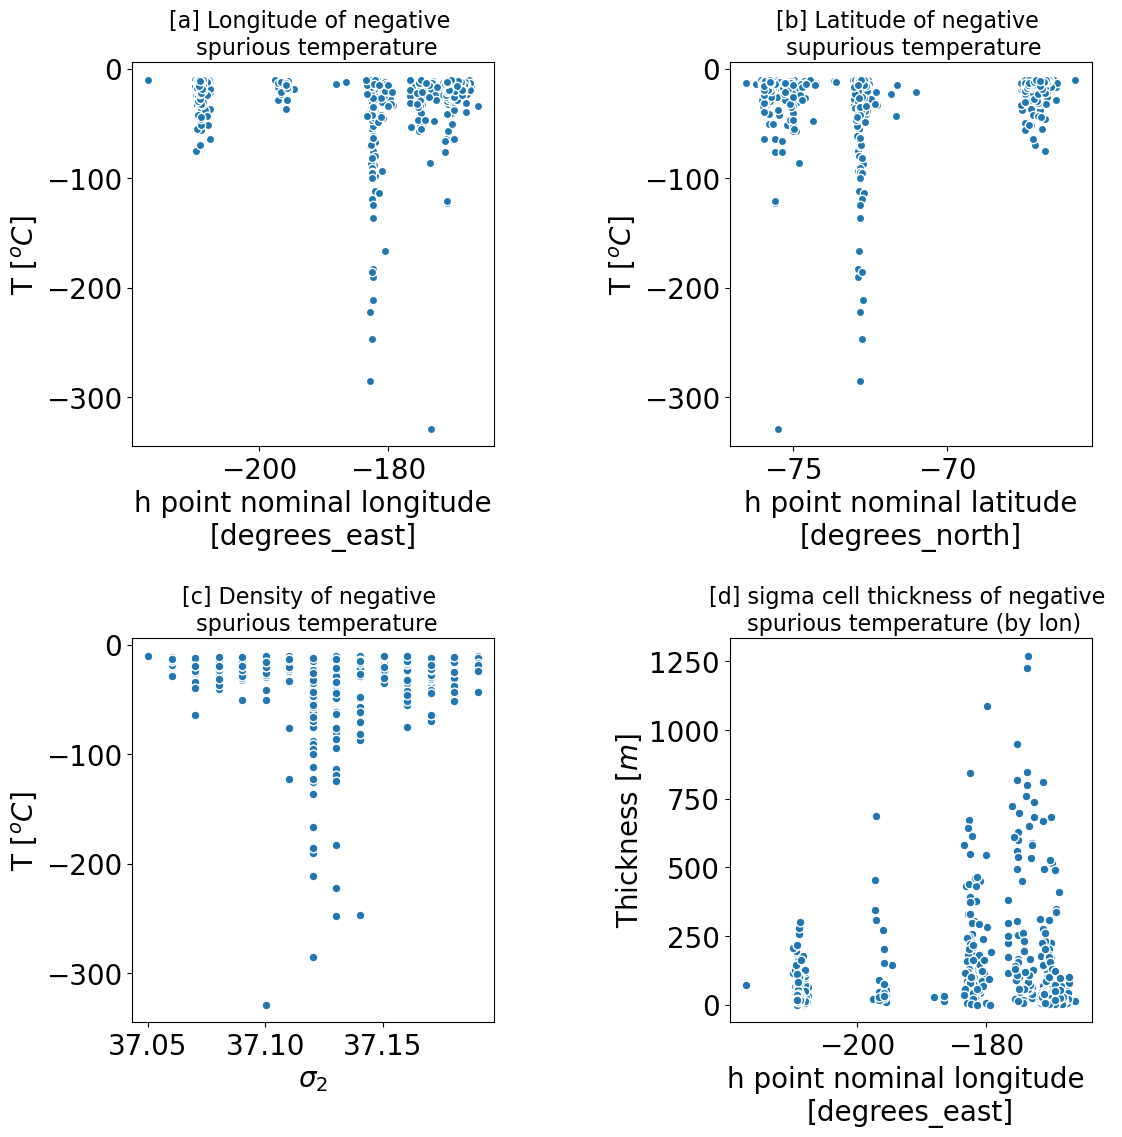

In [25]:
plt.figure(figsize = (12,12))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.65, 
                    hspace=0.5)


plt.subplot(2,2,1)
temp_masked_sliced_negspurious_stacked.plot.scatter(x='xh')
plt.title('[a] Longitude of negative \n spurious temperature', fontsize = 16)
plt.ylabel(r'T [$^oC$]')

plt.subplot(2,2,2)
temp_masked_sliced_negspurious_stacked.plot.scatter(x='yh')
plt.ylabel(r'T [$^oC$]')
plt.title('[b] Latitude of negative \n supurious temperature', fontsize = 16)


plt.subplot(2,2,3)
plt.scatter(temp_masked_sliced_negspurious_stacked.rho2_l-1000, temp_masked_sliced_negspurious_stacked,s=40,edgecolor='w')
plt.ylabel(r'T [$^oC$]')
plt.xlabel(r'$\sigma_2$')
plt.title('[c] Density of negative \n spurious temperature', fontsize = 16)

plt.subplot(2,2,4)
plt.scatter(temp_masked_sliced_negspurious_stacked.xh,drhot_negspurious_stacked,s=40,edgecolor='w')
plt.ylabel(r'Thickness [$m$]')
plt.title('[d] sigma cell thickness of negative \n spurious temperature (by lon)', fontsize = 16)
plt.xlabel('h point nominal longitude \n[degrees_east]')


In [31]:
who

Client	 arg_rhomax	 arg_rhomin	 cc	 ccd	 client	 cmocean	 cp	 drhot	 
drhot_negspurious_stacked	 drhot_posspurious_stacked	 drhot_sliced	 end_time	 end_time0	 exp	 glob	 isobath_depth	 lat_range	 
lat_slice	 logging	 lon_slice	 maxT	 minT	 month2	 n	 nc	 np	 
os	 plt	 rho_0	 session	 start_time	 start_time0	 tarea	 temp	 temp_freezing	 
temp_masked	 temp_masked_sliced	 temp_masked_sliced_negspurious	 temp_masked_sliced_negspurious_stacked	 temp_masked_sliced_posspurious	 temp_masked_sliced_posspurious_stacked	 temp_vmax	 temp_vmin	 temp_zonalmax	 
temp_zonalmax_t0	 temp_zonalmin	 temp_zonalmin_t0	 tempmax_t0masked	 tempmin_t0masked	 time_period	 volcello	 volcello_t0masked	 xr	 
year2	 


## Part 3, Filter out layers.

This is an issue for the simulations for sure, but it might not be that big for the analysis, of these sites with spurious temperature are nt contributing much to changes in heat transport.  SO lets try to evaluate how much difference it makes i cluding those densities wity spurious temperatures in the offline heat transport calculations

In [86]:
Correct_temp_mask = temp.sel(yh=slice(-90,-59)).sel(time=slice(start_time0,end_time0)).copy()
Correct_temp_mask = Correct_temp_mask.where(Correct_temp_mask>-10)
Correct_temp_mask  = Correct_temp_mask.where(Correct_temp_mask< 30)
Correct_temp_mask = (Correct_temp_mask*0)+1
#Correct_temp_mask locate the sites x,y,rho,t coords of correct temperatures  -removed spurious values

In [80]:
#importing 1000 m isobath contour for panan005
isobath_data = xr.open_dataset('/g/data/e14/cs6673/mom6_comparison/Antarctic_slope_contours/Antarctic_slope_contour_1000m_MOM6_005deg.nc')
#getting mask along isobath
Correct_temp_mask_isobath = Correct_temp_mask.where(isobath_data.contour_masked_above>0)

In [88]:
#lets load and savethis correct temp mask, as we will apply that to the heat transport calcuation code, to see if it changes the results
Correct_temp_mask.load()

<xarray.DataArray 'thetao' (time: 12, rho2_l: 99, yh: 1019, xh: 7200)> Size: 35GB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [ 1.,  1.,  1., ...,  1.,  1.,  1.],
         [ 1.,  1.,  1., ...,  1.,  1.,  1.],
         [ 1.,  1.,  1., ...,  1.,  1.,  1.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [ 1.,  1.,  1., ...,  1.,  1.,  1.],
         [ 1.,  1.,  1., ...,  1.,  1.,  1.],
         [ 1.,  1.,  1., ...,  1.,  1.,  1.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [ 1.,  1.,  1., ...,  1.,  1.,  1.],
         [ 1.,  1.,  1., ...,  1.,  1.,  1.],
         [ 1.,  1.,  1., ...,  1.,  1.,  1.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [ 1.,  1.,  1., ...,  1.,  1.,  1.],
         [ 1.,  1.,  1., ...,  1.,  1.,  1.],
         [ 1.,  1.,  1., ...,  1.,  1.,  1.]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [ 1.,  1.,  1., ...,  1.,  1.,  1.],
         [ 1.,  1.,  1., ...,  1.,  1.,  1.],
         [ 1.,  1.,  1., ...,  1.,  1.,  1.]]]], dtype=float32)
Coordinates:
  * xh       (xh) float64 58kB -280.0 -279.9 -279.9 -279.8 ... 79.87 79.92 79.97
  * yh       (yh) float64 8kB -81.1 -81.08 -81.06 ... -59.07 -59.05 -59.02
  * rho2_l   (rho2_l) float64 792B 1.016e+03 1.033e+03 ... 1.037e+03 1.038e+03
  * time     (time) object 96B 2000-01-16 12:00:00 ... 2000-12-16 12:00:00

In [92]:
Correct_temp_mask.name = 'non_spurious_temp_mask'

In [94]:
Correct_temp_mask.to_netcdf('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/correct_temp_masks/correct_temperatures_maks_panan005_year2000.nc')

In [95]:
temp

<xarray.DataArray 'thetao' (time: 36, rho2_l: 99, yh: 1690, xh: 7200)> Size: 173GB
dask.array<getitem, shape=(36, 99, 1690, 7200), dtype=float32, chunksize=(1, 50, 94, 100), chunktype=numpy.ndarray>
Coordinates:
  * xh       (xh) float64 58kB -280.0 -279.9 -279.9 -279.8 ... 79.87 79.92 79.97
  * yh       (yh) float64 14kB -81.1 -81.08 -81.06 ... -37.16 -37.12 -37.08
  * rho2_l   (rho2_l) float64 792B 1.016e+03 1.033e+03 ... 1.037e+03 1.038e+03
  * time     (time) object 288B 1999-01-16 12:00:00 ... 2001-12-16 12:00:00
Attributes:
    units:          degC
    long_name:      Sea Water Potential Temperature
    cell_methods:   area:mean rho2_l:mean yh:mean xh:mean time: mean
    cell_measures:  volume: volcello area: areacello
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_potential_temperature
    ncfiles:        ['/g/data/ol01/outputs/mom6-panan/panant-005-zstar-ACCESS...

2025-08-14 17:08:30,015 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/distributed/worker.py", line 1269, in heartbeat
    response = await retry_operation(
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/distributed/utils_comm.py", line 441, in retry_operation
    return await retry(
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/distributed/utils_comm.py", line 420, in retry
